# **LABORATORIO DE PROCESAMIENTO DIGITAL DE IMAGENES (PDI)**

Pablo Andres Villareal Cardenas - 2043233

Alan Zahir Lopez Rodriguez - 2103115

# **PRÁCTICA 3. *CLUSTERING DE UNA IMAGEN***

---



**Importación de librerías y carga de la imagen**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans as km
from mpl_toolkits.mplot3d import Axes3D as ax

# Cargar imagenes y convertirlas a RGB
img_frutas = cv2.imread('/content/imagen.png')
img_flores = cv2.imread('/flores.jpg')

imgf_rgb = cv2.cvtColor(img_frutas, cv2.COLOR_BGR2RGB)
img_rgb = cv2.cvtColor(img_flores, cv2.COLOR_BGR2RGB)

> En esta sección se importan las librerías que se planean utilizar. Se cargan dos muestras independientes desde el almacenamiento de Colab de manera simultánea: una imagen de unas flores (`flores.jpg`) para las primeras dos etapas, y una con verduras (`imagen.png`) para la aplicación práctica.

> Dado que OpenCV lee los canales en la estructura BGR por defecto, fue necesario convertir esto al espacio estándar RGB empleando `cv2.cvtColor` incluido en open CV para que Matplotlib pueda trabajar de manera adecuada.*


**Ejercicio 1. Representación de la imagen en el espacio RGB**:

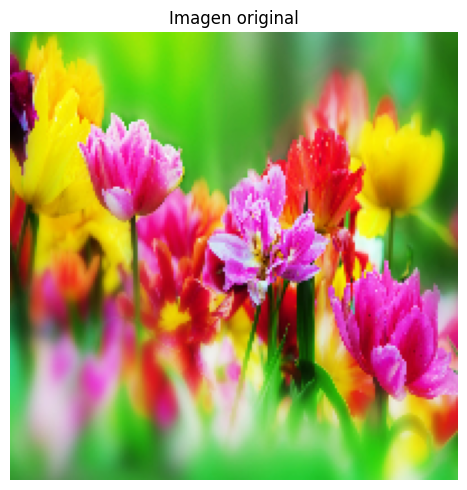

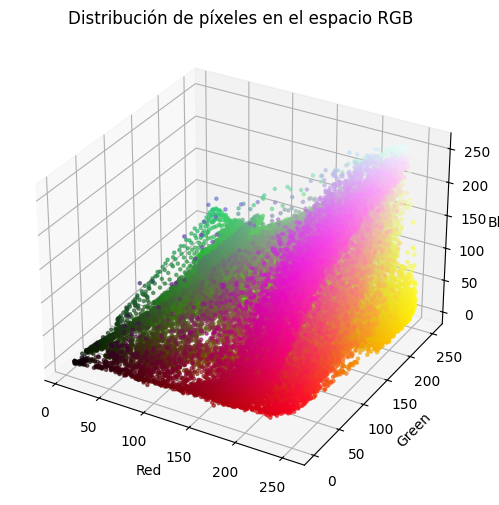

In [ ]:
# Redimensionar para reducir carga computacional
img_small = cv2.resize(img_rgb, (200, 200))
imgf_small = cv2.resize(imgf_rgb, (200, 200))

# Convertir a una matriz de pixeles (n_pixeles x 3)
pixel_vals = img_small.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)

# Visualización de espacio RGB en 3D
fig = plt.figure(figsize=(12, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img_small)
plt.title('Imagen original')
plt.axis('off')

# Ajustar y mostrar imagen original
plt.tight_layout()
plt.show()

# Representación 3D de los píxeles en espacio RGB
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Extraer valores RGB
r, g, b = pixel_vals[:, 0], pixel_vals[:, 1], pixel_vals[:, 2]
ax.scatter(r, g, b, c=pixel_vals / 255.0, marker='o', s=5, alpha=0.6)
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
ax.set_title('Distribución de píxeles en el espacio RGB')

# Mostrar imagaen del espacio RGB
plt.show()

> La imagen original era algo grande como para procesarla rápidamente, por eso modificamos las dimensiones de ambas imágenes a una resolución menor, de **200x200 píxeles** (`cv2.resize`). Esta técnica de submuestreo disminuye el volumen a 40,000 píxeles por imagen, lo cual sirve para mitigar el uso de recursos y hacer que compile más rápido.

> También, se hizo una transformación de la matriz espacial de 3D (Alto, Ancho, Canales) a una matriz lineal 2D de dimensiones `(40000, 3)`. Posteriormente, casteamos los datos a flotantes de 32 bits (`np.float32`), para el procesamiento matemático de Scikit-Learn.

> Se utilizó una extensión de MatPlotLib `Axes3D` para representar cada pixel como una coordenada geométrica dentro de un cubo cartesiano, en donde X, Y, Z corresponden a cada color del RGB, respectivamente.

**Ejercicio 2. Segmentación con K means**


Colores promedio para K=2:
Cluster 1: R=136, G=146, B=40
Cluster 2: R=218, G=128, B=169

Colores promedio para K=4:
Cluster 1: R=219, G=198, B=25
Cluster 2: R=82, G=162, B=51
Cluster 3: R=189, G=43, B=55
Cluster 4: R=218, G=149, B=190

Colores promedio para K=6:
Cluster 1: R=223, G=198, B=23
Cluster 2: R=214, G=189, B=188
Cluster 3: R=59, G=90, B=25
Cluster 4: R=224, G=73, B=180
Cluster 5: R=95, G=187, B=60
Cluster 6: R=198, G=47, B=47


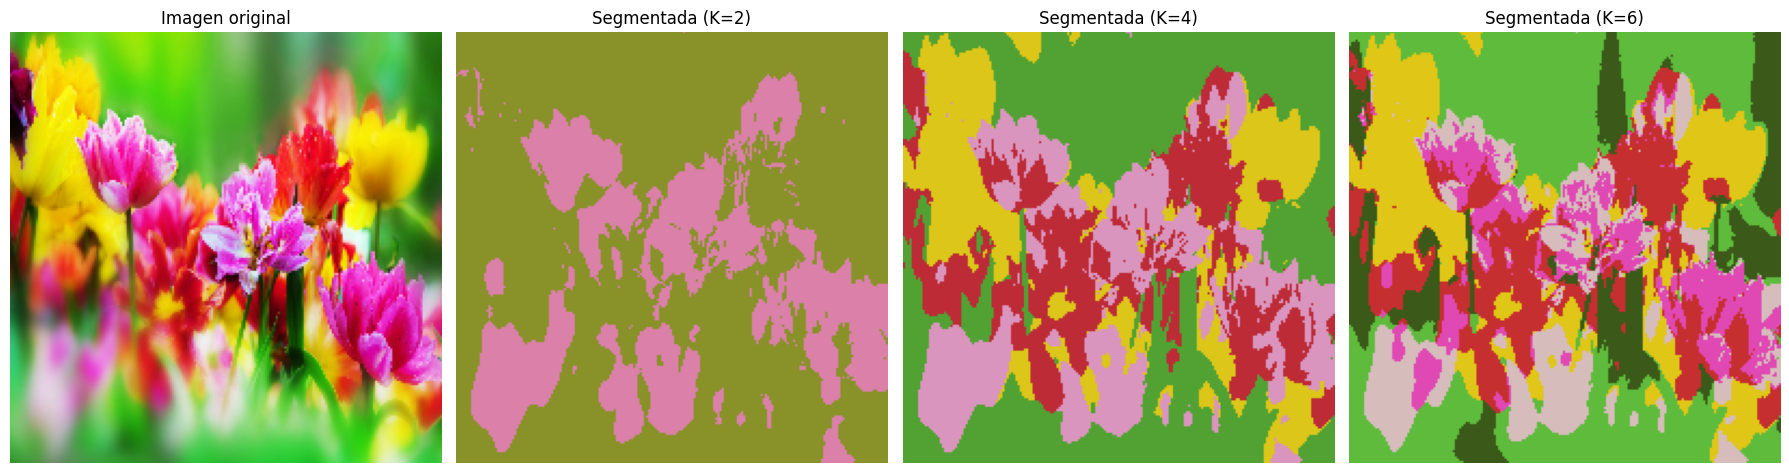

In [ ]:
# Lista con valores K means
valores_k = [2, 4, 6]

# Lista para almacenar y visualizar las imagenes segmentadas
img_vis = []

# Ciclo "for" para aplicar el algoritmo a la lista de K means
for k in valores_k:
    # Clustering K Means
    kmeans = km(n_clusters=k, random_state=42)
    kmeans.fit(pixel_vals)
    labels = kmeans.labels_
    centers = np.uint8(kmeans.cluster_centers_)

    # Ciclo "for" para mostrar colores promedio de cada cluster de la lista de K means
    print(f"\nColores promedio para K={k}:")
    for i, centro in enumerate(centers):
        print(f"Cluster {i+1}: R={centro[0]}, G={centro[1]}, B={centro[2]}")

    # Crear primera imagen segmentada
    img_seg = centers[labels.flatten()]
    img_seg = img_seg.reshape(img_small.shape)

    # Extraer pixeles de la segunda imagen y convertir a float32
    val_pixf = imgf_small.reshape((-1, 3))
    val_pixf = np.float32(val_pixf)

    # Usar modelo ya entrenado para predecir la otra imagen
    labels_f = kmeans.predict(val_pixf)

    # Colores promedio (centros) según las nuevas etiquetas
    imgf_seg_flat = centers[labels_f]

    # Crear la otra imagen segmentada
    imgf_seg = imgf_seg_flat.reshape(imgf_small.shape)

    # Guardar imagen en la lista
    img_vis.append(img_seg)

# Figura para ver la comparación
fig = plt.figure(figsize=(18, 5))

# Mostrar Imagen original
plt.subplot(1, 4, 1)
plt.imshow(img_small)
plt.title('Imagen original')
plt.axis('off')

# Mostrar Imagen segmentada K=2
plt.subplot(1, 4, 2)
plt.imshow(img_vis[0])
plt.title('Segmentada (K=2)')
plt.axis('off')

# Mostrar Imagen segmentada K=4
plt.subplot(1, 4, 3)
plt.imshow(img_vis[1])
plt.title('Segmentada (K=4)')
plt.axis('off')

# Mostrar Imagen segmentada K=6
plt.subplot(1, 4, 4)
plt.imshow(img_vis[2])
plt.title('Segmentada (K=6)')
plt.axis('off')

# Ajustar y mostrar la figura
plt.tight_layout()
plt.show()

> Se buscó una forma de automatizar la segmentación iterativa mediante un ciclo `for`. El algoritmo K-Means localiza de manera iterativa los \(K\) centros o centroides cromáticos óptimos que minimizan la varianza intraclúster de la imagen de las flores.

> Ahora, invocando la propiedad `.cluster_centers_`, se obtienen los vectores numéricos RGB de los colores promedio calculados para cada región detectada y se imprimen secuencialmente en consola. Cada coordenada de píxel original se sustituye por su centroide más cercano (`centers[labels.flatten()]`) y se devuelve a su forma bidimensional (`.reshape`) para consolidar la imagen simplificada.

> Los resultados son indexados en el arreglo `img_vis` para desplegarlos al cierre del ciclo en una única figura comparativa utilizando (`plt.subplot(1, 4, i)`).


**Ejercicio 3. Aplicación práctica**

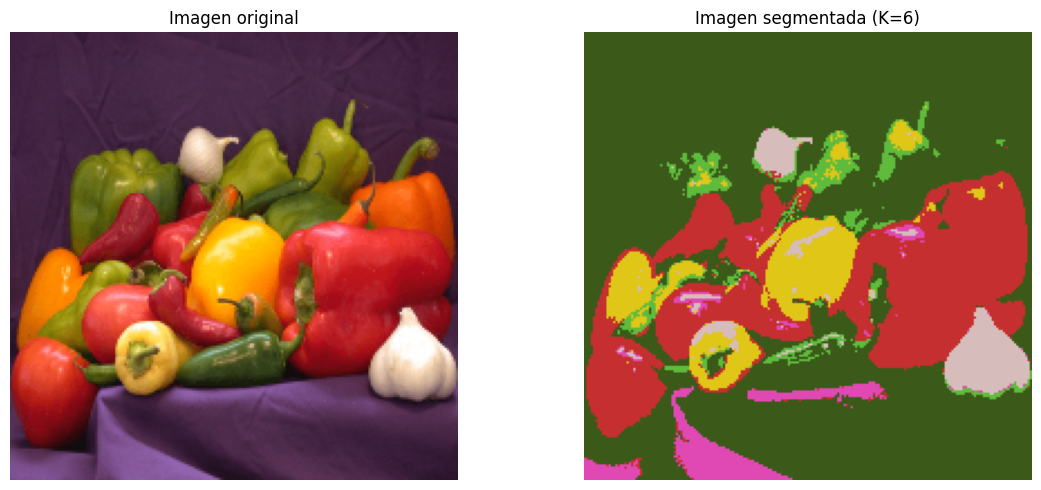

In [ ]:
# Visualizar la comparación
fig = plt.figure(figsize=(12, 5))

# Volver a poner imagen original para comparar
plt.subplot(1, 2, 1)
plt.imshow(imgf_small)
plt.title('Imagen original')
plt.axis('off')

# Mostrar imagen segmentada para compararla con la original
plt.subplot(1, 2, 2)
plt.imshow(imgf_seg)
plt.title(f'Imagen segmentada (K={k})')
plt.axis('off')

# Ajustar y mostrar ambas imagenes
plt.tight_layout()
plt.show()

> Para el caso del ejercicio 3, optamos por utilizar una imagen con mayor variedad de contornos tal como se sugería en el PDF de la práctica. En el código, se extrae la matriz de la segunda captura (`imgf_small`), la homogeniza a `float32` y ejecuta una inferencia predictiva con (`kmeans.predict`).

> El modelo asigna las nuevas texturas frutales a los centroides cromáticos previamente aprendidos en la fase de las flores, capturando la última iteración activa de la variable en memoria \(K=6\).